# **0 Import Library**

In [ ]:
!pip install osm_flex

: 

In [42]:
!pip install climada

In [43]:
!pip install fiona

In [1]:
import osm_flex.download
import osm_flex.extract
import osm_flex.simplify as sy  # For preprocessing
from shapely.geometry import Polygon  # For clipping to Metro Manila bounds
import geopandas as gpd

# **1 Focus on Manila**

In [ ]:
iso3 = "PHL"
path_ctr_dump = osm_flex.download.get_country_geofabrik(iso3)

In [46]:
# Extract all roads using the wrapper for critical infrastructures
gdf_roads = osm_flex.extract.extract_cis(path_ctr_dump, "road")
# Set CRS to EPSG:4326 (as in tutorial)
gdf_roads = gdf_roads.to_crs(epsg=4326)


extract points: 0it [00:06, ?it/s]
extract lines: 100%|██████████| 929958/929958 [01:32<00:00, 10096.47it/s]


extract multipolygons: 100%|██████████| 20198/20198 [01:27<00:00, 229.78it/s]
/tmp/ipython-input-57-1296093872.py:10: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend(loc="upper left")
/tmp/ipython-input-57-1296093872.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc="upper left")


NameError: name 'plt' is not defined

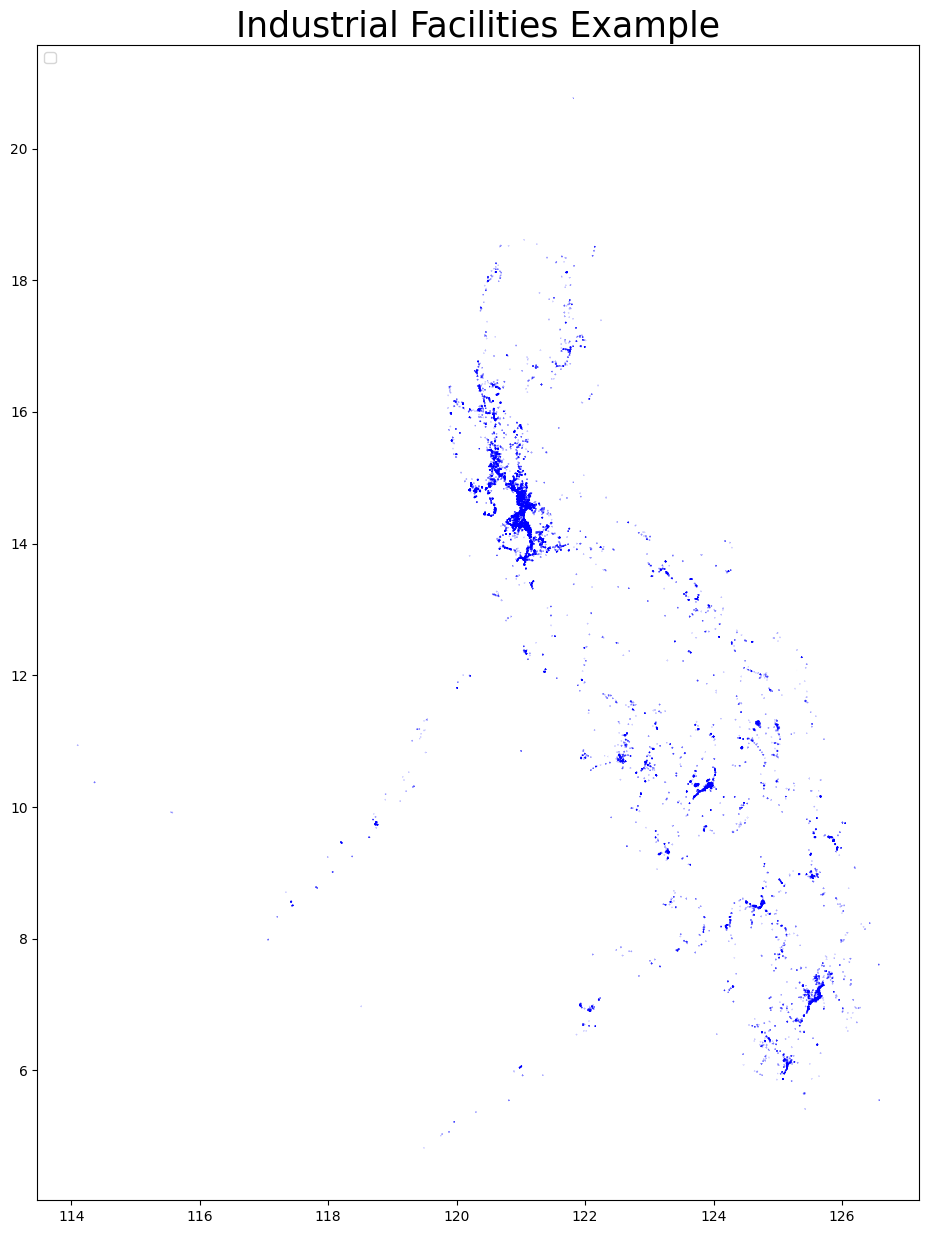

In [57]:
osm_keys = ["landuse", "building"]
osm_query = "landuse='industrial' or building='industrial'"  # Query string for constraints
gdf_industrial = osm_flex.extract.extract(
    path_ctr_dump, "multipolygons", osm_keys, osm_query
)
gdf_industrial = gdf_industrial.to_crs(epsg=4326)

# Plot as in tutorial
ax = gdf_industrial.plot(figsize=(15, 15), alpha=1, markersize=5, color="blue", edgecolor="blue", label="Industrial Facilities")
ax.legend(loc="upper left")
ax.set_title("Industrial Facilities Example", fontsize=25)
plt.show()


In [58]:
# Define Metro Manila bounding box as a Polygon (in EPSG:4326)
metro_manila_bounds = Polygon([(120.39379207352661,14.075338118147869), (120.39379207352661,14.946778538280228), (121.30440398410013,14.946778538280228), (121.30440398410013,14.075338118147869)])
# Clip the GeoDataFrame
gdf_roads_manila = gdf_roads.clip(metro_manila_bounds)


In [59]:
from climada.entity import Exposures

exp_roads_manila = Exposures(gdf_roads_manila)


2025-07-28 08:55:59,918 - climada.util.lines_polys_handler - WARNING - 62 lines with a length < 10*resolution were found. Each of these lines is disaggregate to one point. Reaggregatint values will thus likely lead to overestimattion. Consider chosing a smaller resolution or filter out the short lines. 


<Axes: >

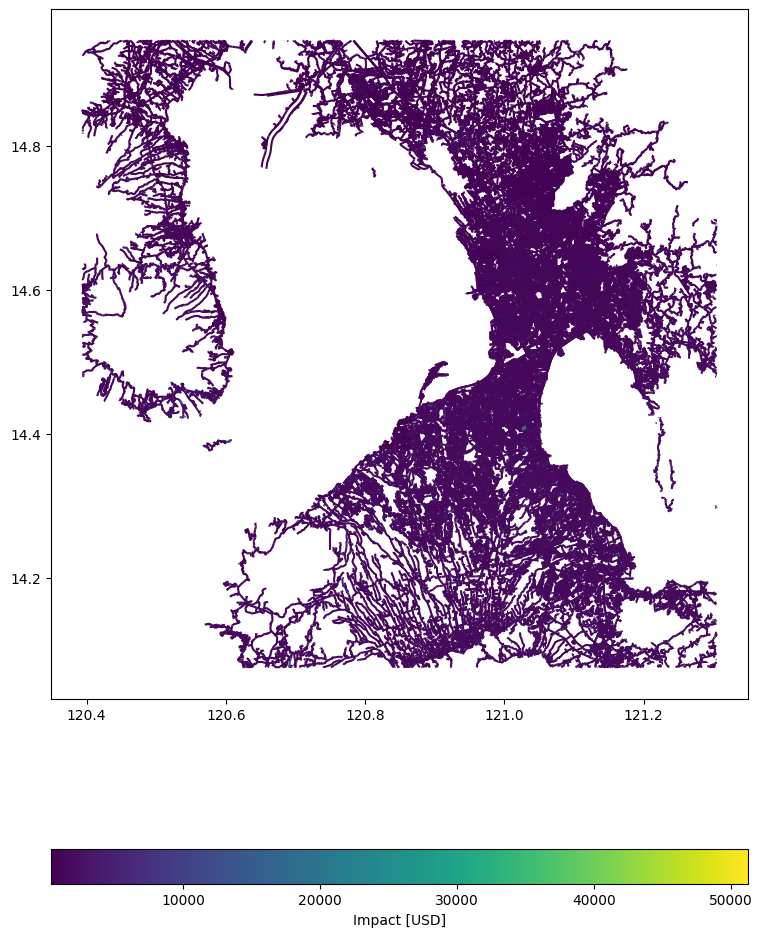

In [56]:
from climada.util.api_client import Client
from climada.entity.impact_funcs import ImpactFuncSet
from climada.entity import ImpfTropCyclone
import climada.util.lines_polys_handler as u_lp

# Load observed tropical cyclones for Philippines
haz = Client().get_hazard("tropical_cyclone", properties={"country_iso3alpha": "PHL", "event_type": "observed"})

# Set up impact function
impf_line = ImpfTropCyclone.from_emanuel_usa()
impf_set = ImpactFuncSet([impf_line])
exp_roads_manila.data["impf_TC"] = 1

# Compute impacts with disaggregation and reaggregation
impact = u_lp.calc_geom_impact(
    exp=exp_roads_manila,
    impf_set=impf_set,
    haz=haz,
    res=500,  # 500m resolution
    to_meters=True,
    disagg_met=u_lp.DisaggMethod.FIX,
    disagg_val=1e5,  # 100k USD per 500m segment
    agg_met=u_lp.AggMethod.SUM
)

# Plot impacts
u_lp.plot_eai_exp_geom(impact)


# **2**

In [60]:
import osm_flex
import osm_flex.download
import osm_flex.extract

iso3 = "PHL"  # ISO3 code for the Philippines
path_dump = osm_flex.download.get_country_geofabrik(iso3)

# Clip the GeoDataFrame
gdf_indus_manila = gdf_roads.clip(gdf_industrial)

exp_indus_manila = Exposures(gdf_indus_manila)


<Axes: >

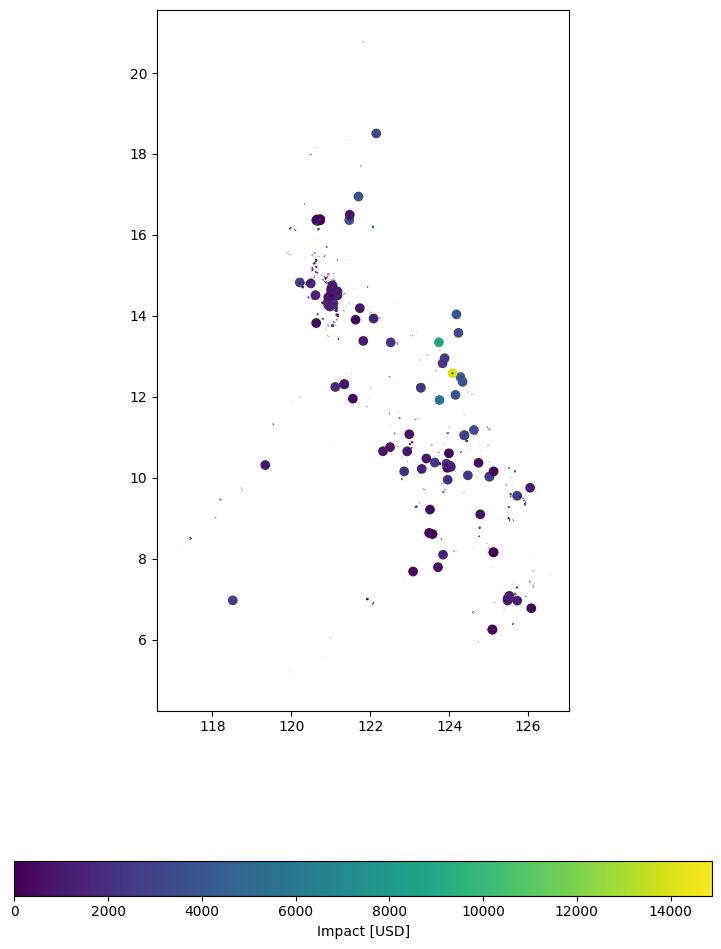

In [66]:
from climada.util.api_client import Client
from climada.entity.impact_funcs import ImpactFuncSet
from climada.entity import ImpfTropCyclone
import climada.util.lines_polys_handler as u_lp
import matplotlib.pyplot as plt
from shapely.geometry import Polygon

# Load observed tropical cyclones for Philippines
haz = Client().get_hazard("tropical_cyclone", properties={"country_iso3alpha": "PHL", "event_type": "observed"})

# Set up impact function
impf_line = ImpfTropCyclone.from_emanuel_usa()
impf_set = ImpactFuncSet([impf_line])
exp_indus_manila.data["impf_TC"] = 1

# Compute impacts with disaggregation and reaggregation
impact = u_lp.calc_geom_impact(
    exp=exp_indus_manila,
    impf_set=impf_set,
    haz=haz,
    res=500,  # 500m resolution
    to_meters=True,
    disagg_met=u_lp.DisaggMethod.FIX,
    disagg_val=1e5,  # 100k USD per 500m segment
    agg_met=u_lp.AggMethod.SUM
)

# Plot impacts
u_lp.plot_eai_exp_geom(impact)
